C:\Users\mnoorche\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


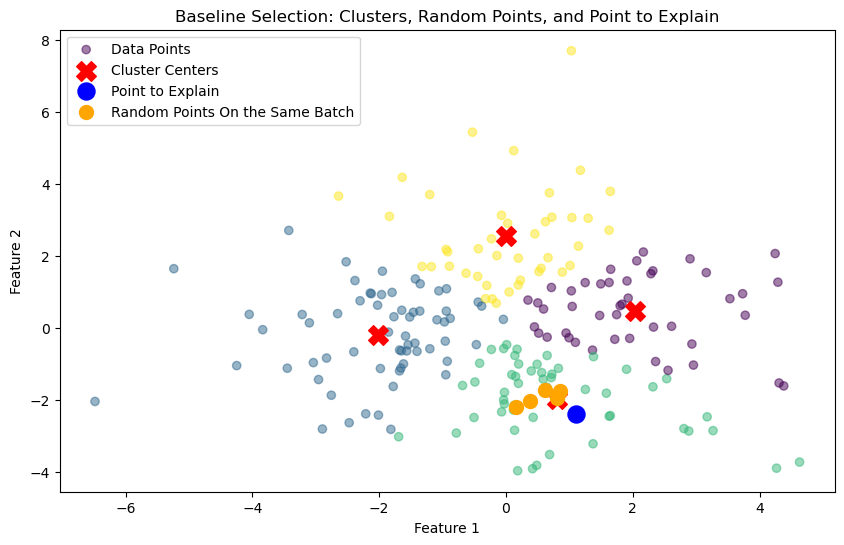

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Generate simulated data
np.random.seed(42)
data = np.random.randn(200, 2) * 2  # 200 random points in 2D

# Fit KMeans for clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(data)

# Cluster centers and labels
centers = kmeans.cluster_centers_
labels = kmeans.labels_

# Select one point to explain (highlighted in blue)
point_to_explain = np.array([[1.1, -2.4]])

# Find the nearest cluster center to the point
nearest_center_idx = np.argmin(np.linalg.norm(centers - point_to_explain, axis=1))
nearest_center = centers[nearest_center_idx]

# Generate a few random points around the nearest cluster center
random_points = nearest_center + np.random.randn(5, 2) * 0.4

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', alpha=0.5, label="Data Points")
plt.scatter(centers[:, 0], centers[:, 1], color='red', marker='X', s=200, label="Cluster Centers")
plt.scatter(point_to_explain[:, 0], point_to_explain[:, 1], color='blue', s=150, label="Point to Explain")
plt.scatter(random_points[:, 0], random_points[:, 1], color='orange', s=100, label="Random Points On the Same Batch")
plt.legend()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Baseline Selection: Clusters, Random Points, and Point to Explain")

# Save the plot as a PDF
plt.savefig("clustering_plot.pdf", format="pdf", bbox_inches="tight")

plt.show()


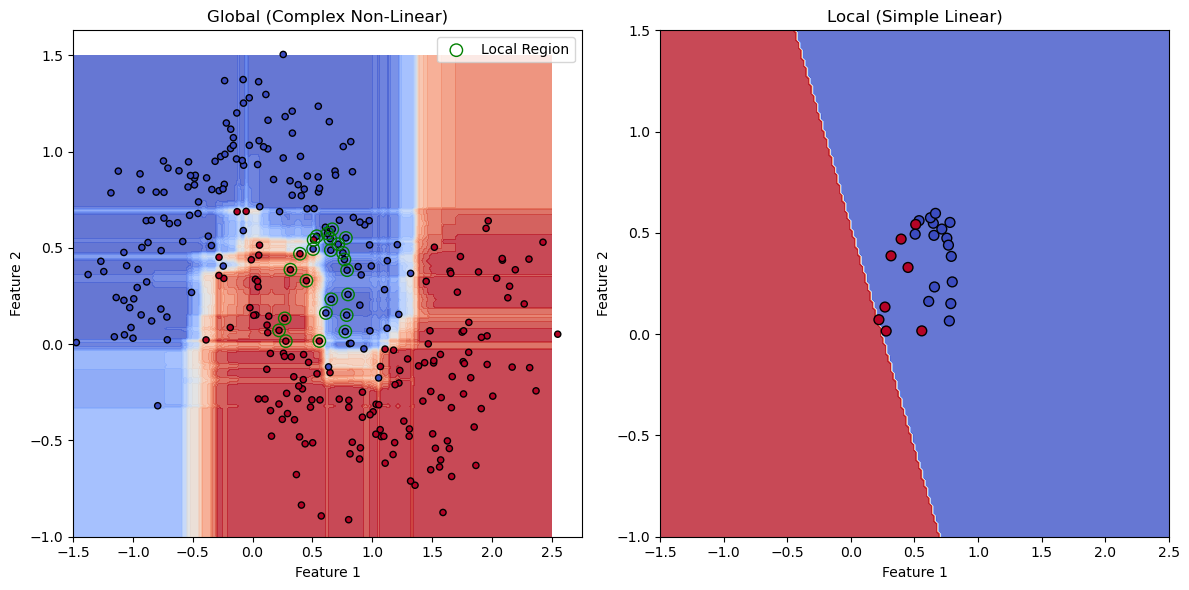

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Generate synthetic data
np.random.seed(42)
X, y = make_moons(n_samples=300, noise=0.2)

# Train a Random Forest (simulated complex model)
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X, y)

# Select a local subset of data containing both classes
local_region = (X[:, 0] > 0.2) & (X[:, 0] < 0.8) & (X[:, 1] > 0) & (X[:, 1] < 0.6)
X_local = X[local_region]
y_local = y[local_region]

# Ensure local data contains samples from both classes
if len(np.unique(y_local)) < 2:
    print("Insufficient class diversity in the local region, expanding the region.")
    X_local = X
    y_local = y

# Train a Logistic Regression model (local surrogate model)
log_reg = LogisticRegression()
log_reg.fit(X_local, y_local)

# Create a grid for visualization
xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 200), np.linspace(-1, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Get predictions for both models
rf_preds = rf.predict_proba(grid)[:, 1].reshape(xx.shape)
log_reg_preds = log_reg.predict(grid).reshape(xx.shape)

# Plot global model decision boundary
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, rf_preds, levels=25, cmap="coolwarm", alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap="coolwarm", s=20)
plt.title("Global (Complex Non-Linear)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(False)

# Highlight the local region
plt.scatter(X_local[:, 0], X_local[:, 1], facecolor="none", edgecolor="green", s=80, label="Local Region")
plt.legend()

# Plot local surrogate decision boundary
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, log_reg_preds, levels=25, cmap="coolwarm", alpha=0.8)
plt.scatter(X_local[:, 0], X_local[:, 1], c=y_local, edgecolor="k", cmap="coolwarm", s=50)
plt.title("Local (Simple Linear)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(False)

plt.tight_layout()
plt.show()


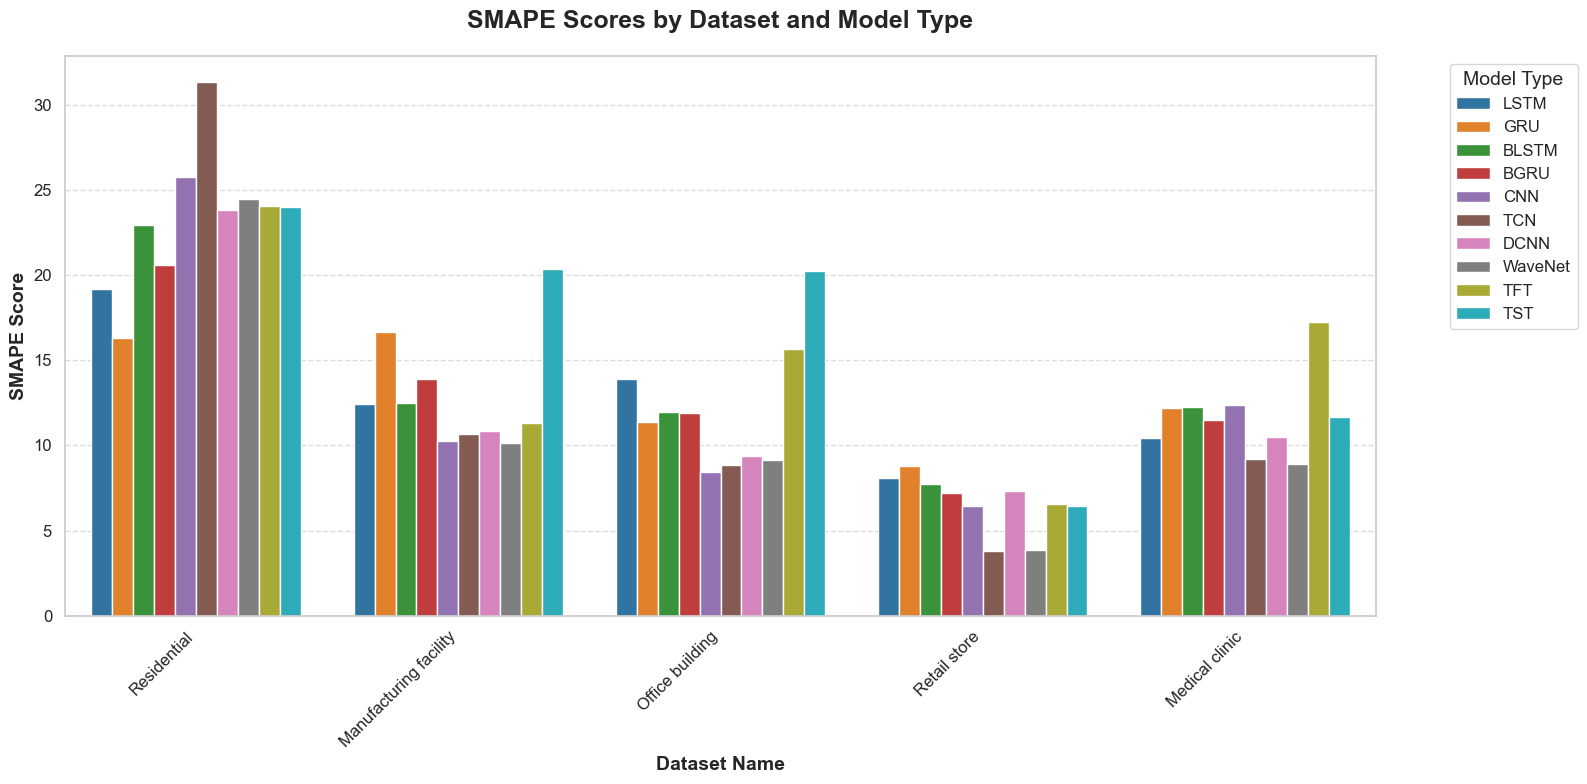

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Your data
data = {
    "dataset_name": [
        "Residential", "Residential", "Residential", "Residential", "Residential", "Residential", "Residential", "Residential", "Residential", "Residential",
        "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility",
        "Office building", "Office building", "Office building", "Office building", "Office building", "Office building", "Office building", "Office building", "Office building", "Office building",
        "Retail store", "Retail store", "Retail store", "Retail store", "Retail store", "Retail store", "Retail store", "Retail store", "Retail store", "Retail store",
        "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic"
    ],
    "model_type": [
        "LSTM", "GRU", "BLSTM", "BGRU", "CNN", "TCN", "DCNN", "WaveNet", "TFT", "TST",
        "LSTM", "GRU", "BLSTM", "BGRU", "CNN", "TCN", "DCNN", "WaveNet", "TFT", "TST",
        "LSTM", "GRU", "BLSTM", "BGRU", "CNN", "TCN", "DCNN", "WaveNet", "TFT", "TST",
        "LSTM", "GRU", "BLSTM", "BGRU", "CNN", "TCN", "DCNN", "WaveNet", "TFT", "TST",
        "LSTM", "GRU", "BLSTM", "BGRU", "CNN", "TCN", "DCNN", "WaveNet", "TFT", "TST"
    ],
    "smape_score": [
        19.16, 16.3, 22.92, 20.61, 25.75, 31.3, 23.81, 24.48, 24.03, 23.97,
        12.44, 16.67, 12.5, 13.88, 10.28, 10.64, 10.86, 10.11, 11.32, 20.37,
        13.88, 11.35, 11.95, 11.88, 8.45, 8.86, 9.38, 9.17, 15.68, 20.23,
        8.1, 8.78, 7.76, 7.18, 6.42, 3.82, 7.35, 3.85, 6.55, 6.43,
        10.45, 12.21, 12.23, 11.48, 12.35, 9.21, 10.52, 8.93, 17.25, 11.64
    ]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Set up the plot
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

# Custom bright and distinct color palette
custom_palette = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",  # LSTM, GRU, BLSTM, BGRU, CNN
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",  # TCN, DCNN, WaveNet, TFT, TST
]

# Create a grouped bar plot with the custom palette
sns.barplot(x="dataset_name", y="smape_score", hue="model_type", data=df, palette=custom_palette)

# Add labels and title
plt.xlabel("Dataset Name", fontsize=14, fontweight="bold")
plt.ylabel("SMAPE Score", fontsize=14, fontweight="bold")
plt.title("SMAPE Scores by Dataset and Model Type", fontsize=18, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=12)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=12)

# Move legend outside the plot
plt.legend(title="Model Type", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12, title_fontsize=14)

# Add gridlines for better readability
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.savefig("smape_plot.pdf", format="pdf", bbox_inches="tight")

# Show the plot
plt.tight_layout()
plt.show()

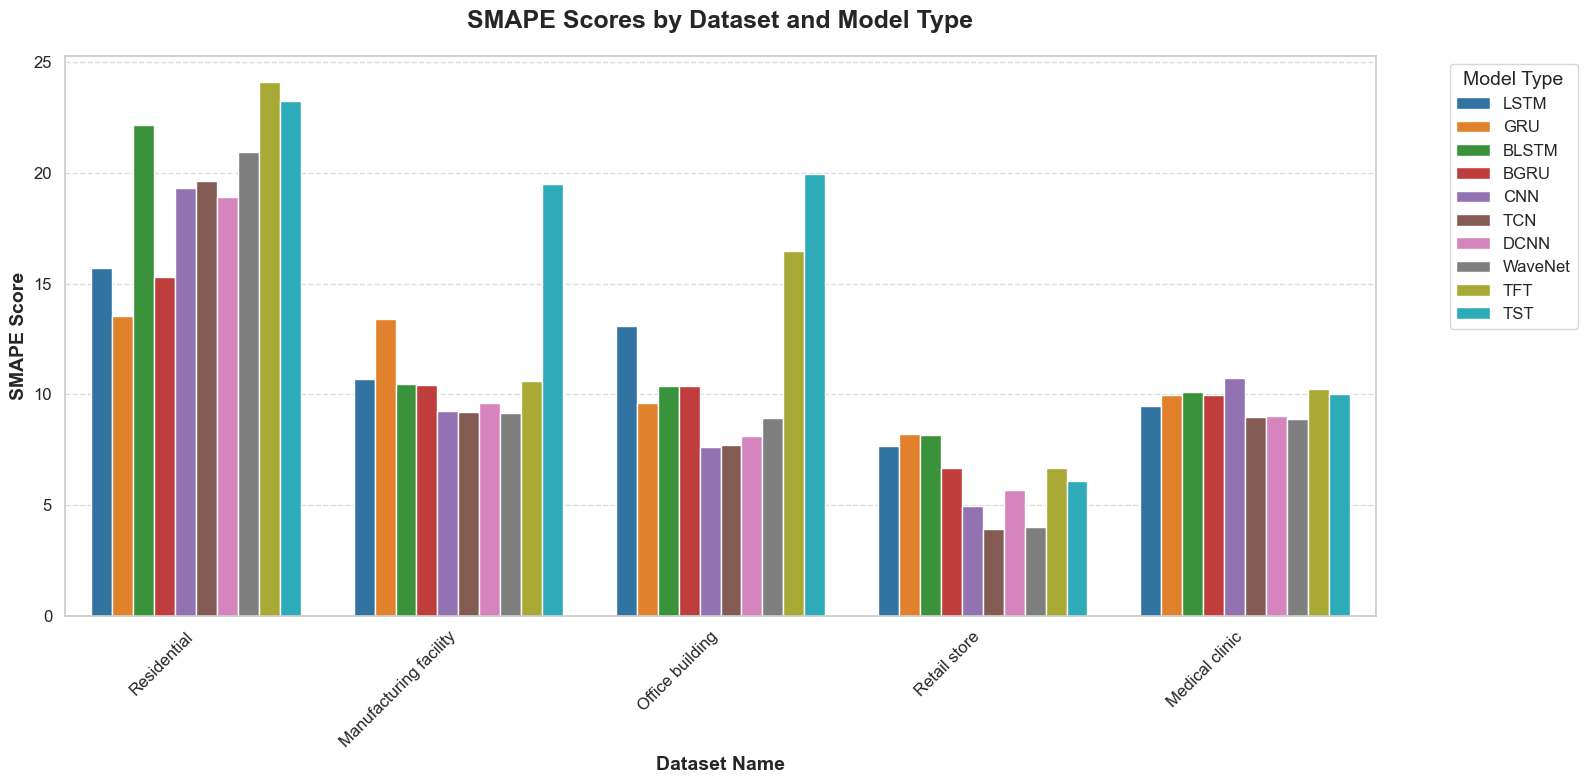

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Your data
data = {
    "dataset_name": [
        "Residential", "Residential", "Residential", "Residential", "Residential", "Residential", "Residential", "Residential", "Residential", "Residential",
        "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility", "Manufacturing facility",
        "Office building", "Office building", "Office building", "Office building", "Office building", "Office building", "Office building", "Office building", "Office building", "Office building",
        "Retail store", "Retail store", "Retail store", "Retail store", "Retail store", "Retail store", "Retail store", "Retail store", "Retail store", "Retail store",
        "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic", "Medical clinic"
    ],
    "model_type": [
        "LSTM", "GRU", "BLSTM", "BGRU", "CNN", "TCN", "DCNN", "WaveNet", "TFT", "TST",
        "LSTM", "GRU", "BLSTM", "BGRU", "CNN", "TCN", "DCNN", "WaveNet", "TFT", "TST",
        "LSTM", "GRU", "BLSTM", "BGRU", "CNN", "TCN", "DCNN", "WaveNet", "TFT", "TST",
        "LSTM", "GRU", "BLSTM", "BGRU", "CNN", "TCN", "DCNN", "WaveNet", "TFT", "TST",
        "LSTM", "GRU", "BLSTM", "BGRU", "CNN", "TCN", "DCNN", "WaveNet", "TFT", "TST"
    ],
    "smape_score": [
        15.7, 13.56, 22.18, 15.3, 19.32, 19.66, 18.92, 20.96, 24.09, 23.25,
        10.71, 13.39, 10.49, 10.44, 9.26, 9.19, 9.59, 9.17, 10.61, 19.52,
        13.1, 9.59, 10.39, 10.39, 7.64, 7.71, 8.14, 8.94, 16.48, 19.94,
        7.67, 8.19, 8.16, 6.67, 4.97, 3.91, 5.7, 3.99, 6.68, 6.07,
        9.48, 9.99, 10.1, 9.95, 10.75, 8.99, 9.01, 8.88, 10.25, 10.01
    ]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Set up the plot
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

# Custom bright and distinct color palette
custom_palette = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",  # LSTM, GRU, BLSTM, BGRU, CNN
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",  # TCN, DCNN, WaveNet, TFT, TST
]

# Create a grouped bar plot with the custom palette
sns.barplot(x="dataset_name", y="smape_score", hue="model_type", data=df, palette=custom_palette)

# Add labels and title
plt.xlabel("Dataset Name", fontsize=14, fontweight="bold")
plt.ylabel("SMAPE Score", fontsize=14, fontweight="bold")
plt.title("SMAPE Scores by Dataset and Model Type", fontsize=18, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=12)  # Rotate x-axis labels for better readability
plt.yticks(fontsize=12)

# Move legend outside the plot
plt.legend(title="Model Type", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12, title_fontsize=14)

# Add gridlines for better readability
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.savefig("rf_smape_plot.pdf", format="pdf", bbox_inches="tight")

# Show the plot
plt.tight_layout()
plt.show()